In [1]:
import json
import os
from typing import List

from matplotlib import pyplot as plt

MODEL_IDS_24_H: List[str] = [
    'LinearRegression2022_02_08_15_40_14_910282',
    'SimpleNeuralNet2022_02_08_12_56_24_635436',
    'SimpleNeuralNet2022_02_14_15_16_38_768994',
    'TimeSeriesTransformer2022_02_07_21_41_35_195139',
    # 'TimeSeriesTransformer2022_02_08_00_14_35_897198',
    # 'TimeSeriesTransformer2022_02_07_23_48_05_910516',
    'TimeSeriesTransformerWithConvolutionalAttention2022_02_07_21_55_14_101949',
    # 'TimeSeriesTransformerWithConvolutionalAttention2022_02_07_22_20_04_159231',
    # 'TimeSeriesTransformerWithConvolutionalAttention2022_02_07_22_42_57_369977',
    'Informer2022_02_07_21_23_12_947796'
]
LABEL_IDS_24_H: List[str] = [
    'Linear Regression',
    'Neural Net (2 Layers a 256 Neurons)',
    'Neural Net (2 Layers a 2048 Neurons)',
    'Transformer (generative)',
    # 'Transformer (1 step ahead)',
    # 'Transformer (teacher forcing)',
    'Conv. Transformer (generative)',
    # 'Conv. Transformer (1 step ahead)',
    # 'Conv. Transformer (teacher forcing)',
    'Informer (generative)'    
]


model_ids = MODEL_IDS_24_H
labels = LABEL_IDS_24_H

assert len(model_ids) == len(labels)

experiments = []
for model_id in model_ids:
    with open(os.path.join('..', 'experiments', 'final', model_id + '.json')) as file:
        experiment_data = json.load(file)
        experiments.append(experiment_data)        

Manually appending data obtaining from modified Transformer model.

Modified model contains 2 extra features: solar and wind generation.

In [2]:
evaluation_afeka = {
   "total_mape_loss":0.5106260776519775,
   "total_mase_loss":8.050661087036133,
   "mape_losses_by_prediction_variable":{
      "0":0.31625068187713623,
      "1":0.39102551341056824,
      "2":0.42932718992233276,
      "3":0.4575270116329193,
      "4":0.48071444034576416,
      "5":0.4989858865737915,
      "6":0.5154229402542114,
      "7":0.528962254524231,
      "8":0.5393084287643433,
      "9":0.5466619729995728,
      "10":0.5487309694290161,
      "11":0.5459544062614441,
      "12":0.5425629019737244,
      "13":0.5409771800041199,
      "14":0.5408939123153687,
      "15":0.5399047136306763,
      "16":0.5381338596343994,
      "17":0.5353997349739075,
      "18":0.529510498046875,
      "19":0.5218629240989685,
      "20":0.5189660787582397,
      "21":0.5281945466995239,
      "22":0.549685537815094,
      "23":0.5700628757476807
   },
   "mase_losses_by_prediction_variable":{
      "0":4.9524383544921875,
      "1":6.13336181640625,
      "2":6.77053689956665,
      "3":7.24476957321167,
      "4":7.619886875152588,
      "5":7.893483638763428,
      "6":8.13917350769043,
      "7":8.3499116897583,
      "8":8.508173942565918,
      "9":8.616009712219238,
      "10":8.644978523254395,
      "11":8.59798526763916,
      "12":8.54246997833252,
      "13":8.516671180725098,
      "14":8.515069961547852,
      "15":8.4979829788208,
      "16":8.46529483795166,
      "17":8.420345306396484,
      "18":8.34043025970459,
      "19":8.2371244430542,
      "20":8.197872161865234,
      "21":8.341846466064453,
      "22":8.673980712890625,
      "23":8.989887237548828
   }
}


experiments.append(
{
    'experimentName': 'Transformer Afeka', 
    'trainingReport': None, 
    'evaluation': evaluation_afeka
})

labels.append('Transformer (Afeka)')

Compare the average losses

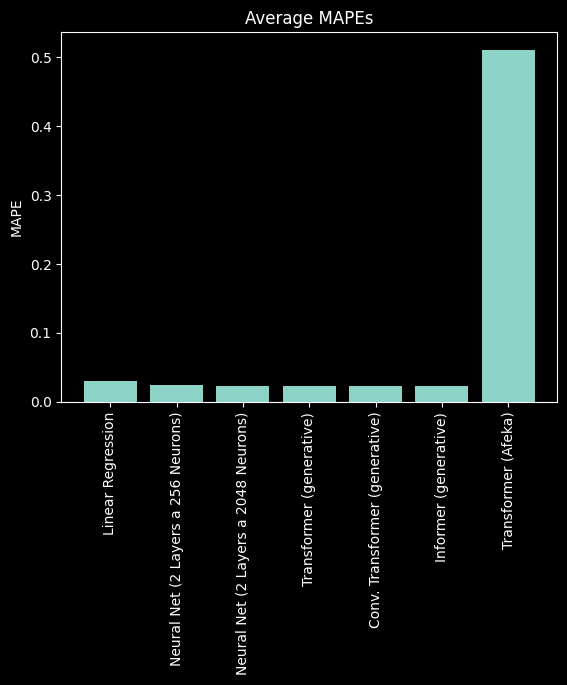

In [3]:
def create_loss_comparison_diagram(losses: List[float], title: str, bar_names: List[str], y_axis_label: str) -> None:
    """
    Creates a bar diagram which compares the losses of different models
    :param losses: the loss of each model to plot
    :param title: the name of the diagram
    :param bar_names: the name of each bar (should identify the model)
    :param y_axis_label: the name of the y axis
    """
    assert len(losses) == len(bar_names)
    plt.bar(bar_names, losses)
    plt.xticks(rotation='vertical')
    plt.ylabel(y_axis_label)
    plt.title(title)
    plt.show()


mape_losses = [experiment['evaluation']['total_mape_loss'] for experiment in experiments]
create_loss_comparison_diagram(mape_losses, 'Average MAPEs', labels, 'MAPE')

Compare the losses by prediction variable:

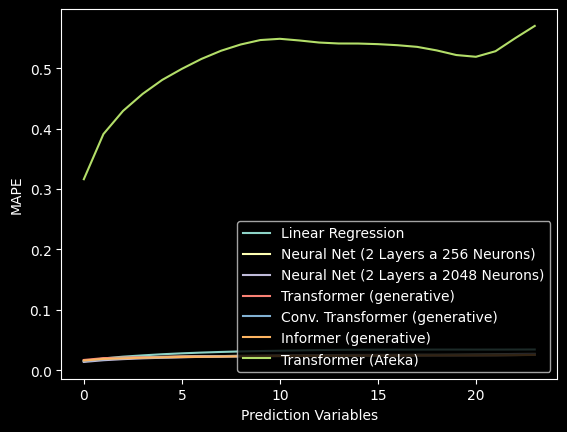

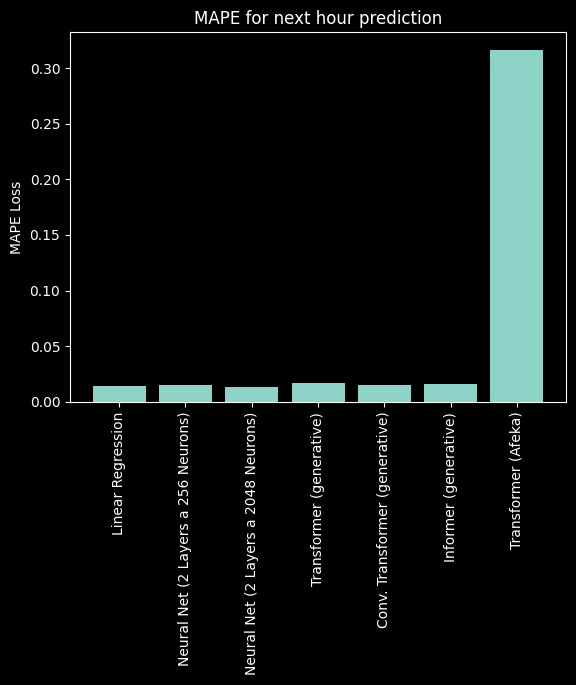

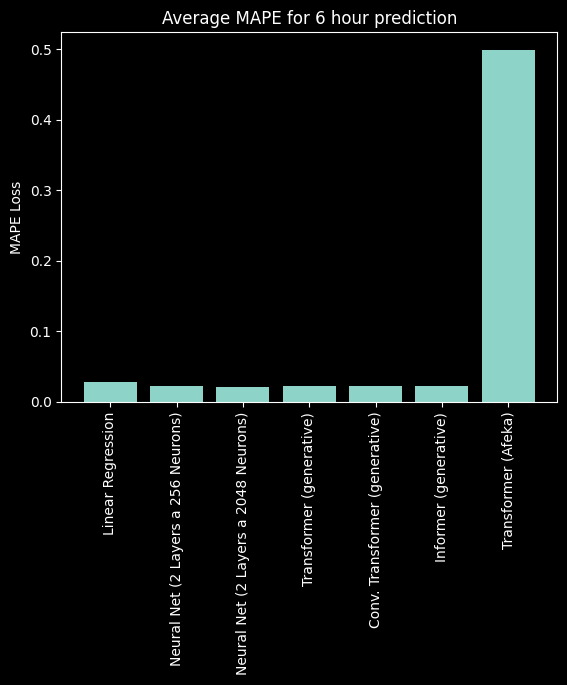

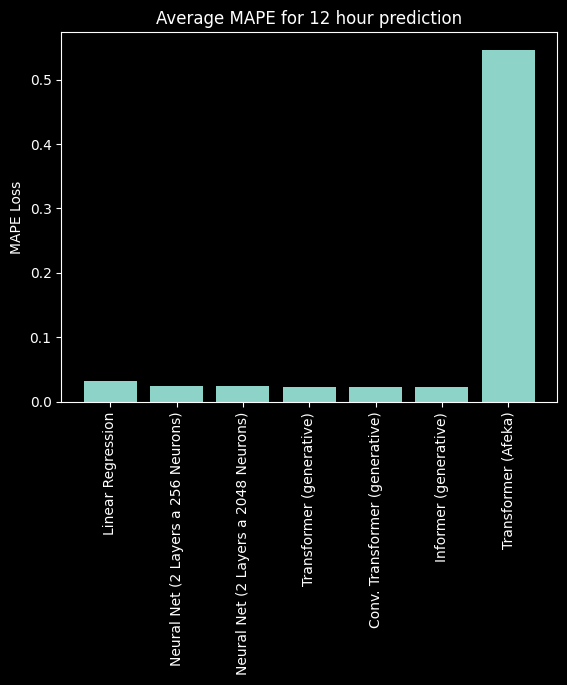

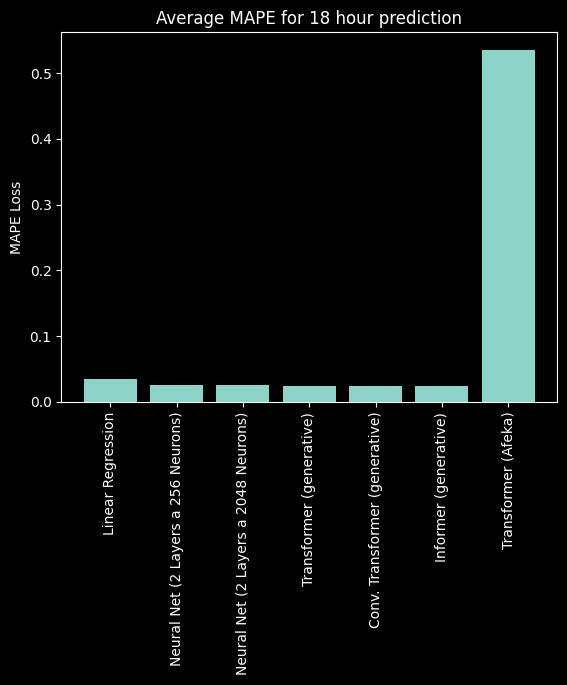

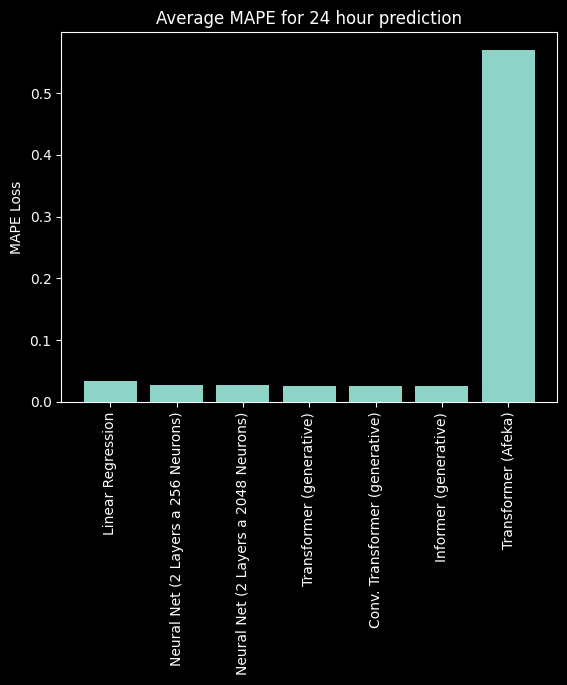

In [4]:
# Compare over all variables
fig = plt.figure()
next_hour_mape_losses = []
mape_losses_6_hours = []
mape_losses_12_hours = []
mape_losses_18_hours = []
mape_losses_24_hours = []
for index, experiment in enumerate(experiments):
    mape_losses_by_predicted_variable = []
    for variable in experiment['evaluation']['mape_losses_by_prediction_variable']:
        mape_loss = experiment['evaluation']['mape_losses_by_prediction_variable'][variable]
        mape_losses_by_predicted_variable.append(mape_loss)
        if variable == '0':
            next_hour_mape_losses.append(mape_loss)
        elif variable == '5':
            mape_losses_6_hours.append(mape_loss)
        elif variable == '11':
            mape_losses_12_hours.append(mape_loss)
        elif variable == '17':
            mape_losses_18_hours.append(mape_loss)
        elif variable == '23':
            mape_losses_24_hours.append(mape_loss)
    plt.plot(mape_losses_by_predicted_variable, label=labels[index])
plt.xlabel('Prediction Variables')
plt.ylabel('MAPE')
plt.legend(loc='lower right')
plt.show()

# Compare over single variables
create_loss_comparison_diagram(next_hour_mape_losses, 'MAPE for next hour prediction', labels, 'MAPE Loss')
create_loss_comparison_diagram(mape_losses_6_hours, 'Average MAPE for 6 hour prediction', labels, 'MAPE Loss')
create_loss_comparison_diagram(mape_losses_12_hours, 'Average MAPE for 12 hour prediction', labels, 'MAPE Loss')
create_loss_comparison_diagram(mape_losses_18_hours, 'Average MAPE for 18 hour prediction', labels, 'MAPE Loss')
create_loss_comparison_diagram(mape_losses_24_hours, 'Average MAPE for 24 hour prediction', labels, 'MAPE Loss')


Show the training processes:

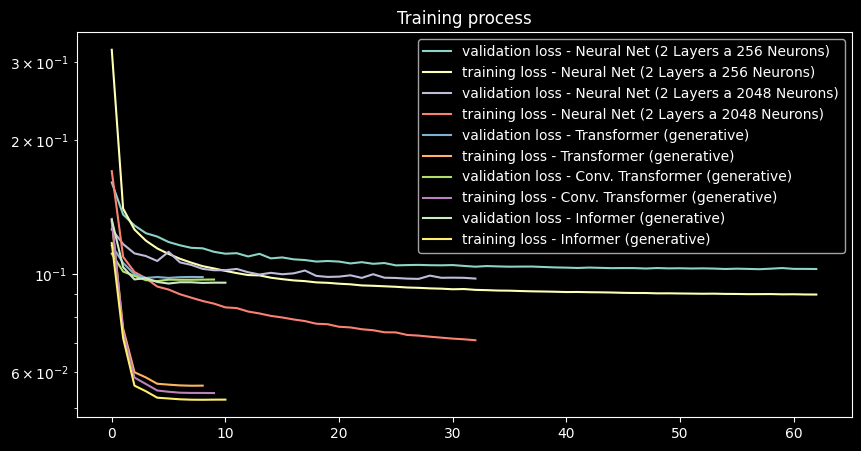

In [5]:
fig = plt.figure(figsize=(10, 5))
for index, experiment in enumerate(experiments):
    if 'trainingReport' in experiment and experiment['trainingReport']:
        epochs = experiment['trainingReport']['epochs']
        validation_losses = [epoch['validationLoss'] for epoch in epochs]
        training_losses = [epoch['trainingLoss'] for epoch in epochs]
        name = labels[index]
        plt.plot(validation_losses, label='validation loss - ' + name)
        plt.plot(training_losses, label='training loss - ' + name)
        plt.legend(loc='upper right')
        plt.yscale('log')
        plt.title('Training process')
plt.show()

# Conclusion

Experiment results indicate that the incorporation of solar and wind generation data led to a catastrophic failure of the Transformer model, with the Mean Absolute Percentage Error (MAPE) skyrocketing to 50%.
